<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/5_Aprendizaje_supervisado/1_Regresion_Lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
SEED = 42
np.random.seed(SEED)

In [27]:
# Carga del dataset
df = pd.read_csv('train_df_ventas.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (3636, 5)


,TV,Social Media,Influencer,Radio,Sales
0,17.579874,1.218985,Macro,22.282240,173.612079
1,14.588548,5.478278,Micro,22.097499,140.540703
2,25.183695,2.279885,Mega,22.197715,197.352805
3,12.898275,1.831455,Nano,21.741263,184.047821
4,28.380520,4.338470,Nano,22.607219,318.627485
5,6.244162,0.759347,Macro,21.397275,42.196108
6,17.739136,7.069536,Mega,22.678579,229.302551
7,10.400534,2.607022,Nano,21.664829,89.840061
8,19.283719,0.481806,Nano,22.889545,224.112962
9,5.906967,3.587998,Mega,21.922836,140.024739


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            3636 non-null   float64
 1   Social Media  3636 non-null   float64
 2   Influencer    3636 non-null   object 
 3   Radio         3636 non-null   float64
 4   Sales         3636 non-null   float64
dtypes: float64(4), object(1)
memory usage: 142.2+ KB


In [29]:
df.describe()

,TV,Social Media,Radio,Sales
count,3636.000000,3636.000000,3636.000000,3636.000000
mean,18.165917,3.311115,22.085014,192.407780
std,9.671536,2.221452,0.475698,92.553501
min,0.000684,0.000977,21.035102,31.199409
25%,10.598536,1.483576,21.702204,113.173995
50%,17.889588,3.041391,22.045490,189.531695
75%,25.603279,4.804043,22.448079,271.051331
max,48.871161,13.083957,23.224233,364.079751


In [30]:
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
TV              0
Social Media    0
Influencer      0
Radio           0
Sales           0
dtype: int64


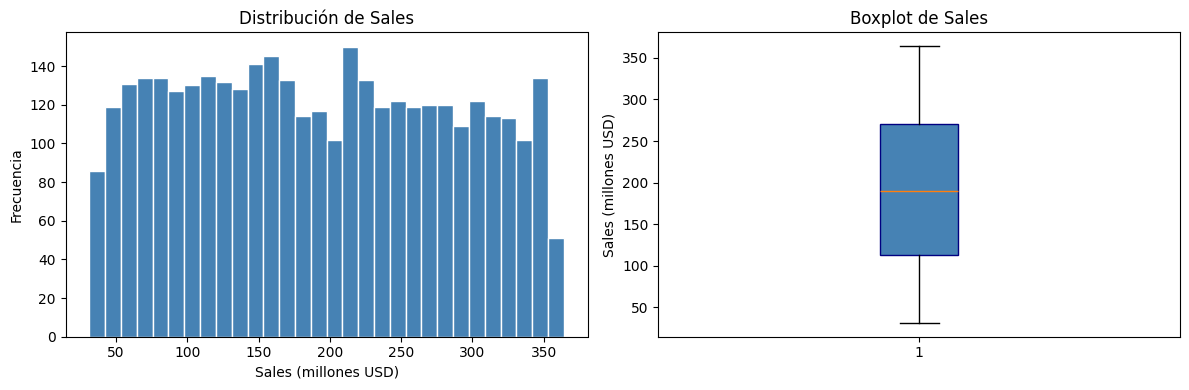

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Sales'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Sales')
axes[0].set_xlabel('Sales (millones USD)')
axes[0].set_ylabel('Frecuencia')
axes[1].boxplot(df['Sales'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot de Sales')
axes[1].set_ylabel('Sales (millones USD)')
plt.tight_layout()
plt.show()

Distribución de Influencer:
Influencer
Mega     925
Micro    920
Macro    905
Nano     886
Name: count, dtype: int64


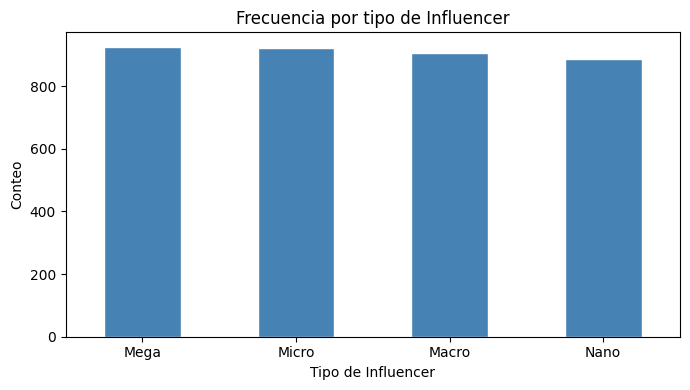

In [32]:

print('Distribución de Influencer:')
print(df['Influencer'].value_counts())
fig, ax = plt.subplots(figsize=(7, 4))
df['Influencer'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Frecuencia por tipo de Influencer')
ax.set_xlabel('Tipo de Influencer')
ax.set_ylabel('Conteo')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

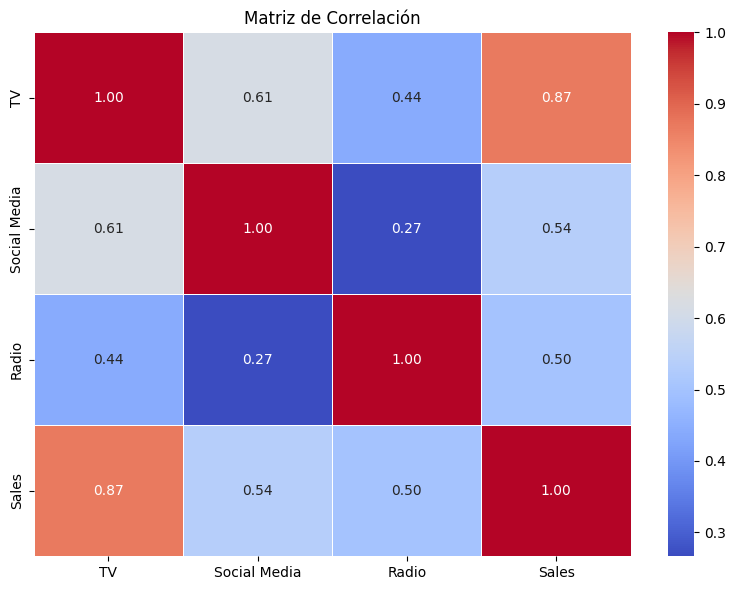

In [33]:
# Correlación entre variables numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(8, 6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

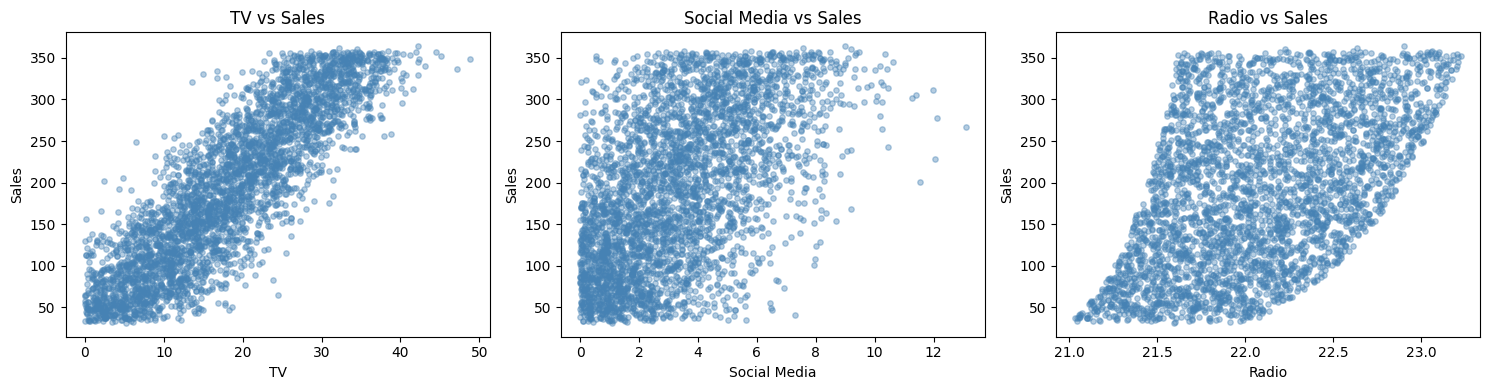

In [34]:
# Scatter plots: variables numéricas vs Sales
features_num = [c for c in numeric_cols if c != 'Sales']
fig, axes = plt.subplots(1, len(features_num), figsize=(5 * len(features_num), 4))
if len(features_num) == 1:
    axes = [axes]
for ax, col in zip(axes, features_num):
    ax.scatter(df[col], df['Sales'], alpha=0.4, color='steelblue', s=15)
    ax.set_xlabel(col)
    ax.set_ylabel('Sales')
    ax.set_title(f'{col} vs Sales')
plt.tight_layout()
plt.show()

In [35]:
df_proc = df.copy()
df_proc = pd.get_dummies(df_proc, columns=['Influencer'], drop_first=True)
print('Columnas tras preprocesamiento:')
print(df_proc.columns.tolist())
df_proc.head()

Columnas tras preprocesamiento:
['TV', 'Social Media', 'Radio', 'Sales', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']


,TV,Social Media,Radio,Sales,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,17.579874,1.218985,22.282240,173.612079,False,False,False
1,14.588548,5.478278,22.097499,140.540703,False,True,False
2,25.183695,2.279885,22.197715,197.352805,True,False,False
3,12.898275,1.831455,21.741263,184.047821,False,False,True
4,28.380520,4.338470,22.607219,318.627485,False,False,True


In [36]:
X = df_proc.drop(columns=['Sales'])
y = df_proc['Sales']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

print(f'Train: {X_train.shape}  |  Validation: {X_val.shape}')
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

Train: (2908, 6)  |  Validation: (728, 6)


In [37]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
results = {}  # diccionario para guardar resultados

# Regresion lineal

In [39]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_val_sc)
rmse_lr = rmse(y_val, y_pred_lr)
results['Regresión Lineal'] = rmse_lr
print(f'RMSE Regresión Lineal: {rmse_lr:.4f}')

RMSE Regresión Lineal: 44.9918


# Gradient Boosting forest  

In [41]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

# Predecir en el conjunto de validación
y_pred_gb = gb_model.predict(X_val)
rmse_gb = rmse(y_val, y_pred_gb)
results['Gradient Boosting'] = rmse_gb
print("Evaluación de Gradient Boosting:")
print(f"RMSE: {rmse_gb:.4f}")

Evaluación de Gradient Boosting:
RMSE: 42.3649


# Regresion plinomica

In [42]:
poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())])

param_grid_poly = {'poly__degree': [2, 3, 4]}

gs_poly = GridSearchCV(
    poly_pipe,
    param_grid_poly,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
gs_poly.fit(X_train, y_train)

best_degree = gs_poly.best_params_['poly__degree']
y_pred_poly = gs_poly.predict(X_val)
rmse_poly = rmse(y_val, y_pred_poly)

results['Regresión Polinómica'] = rmse_poly
print(f'Mejor grado: {best_degree}')
print(f'RMSE Regresión Polinómica: {rmse_poly:.4f}')

Mejor grado: 3
RMSE Regresión Polinómica: 42.2951


# KNN

In [43]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10, 15, 20],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

gs_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_knn,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
gs_knn.fit(X_train_sc, y_train)
y_pred_knn = gs_knn.predict(X_val_sc)
rmse_knn = rmse(y_val, y_pred_knn)
results['KNN Regressor'] = rmse_knn
print(f'Mejores parámetros KNN: {gs_knn.best_params_}')
print(f'RMSE KNN Regressor: {rmse_knn:.4f}')

Mejores parámetros KNN: {'metric': 'manhattan', 'n_neighbors': 20, 'weights': 'distance'}
RMSE KNN Regressor: 44.5333


# Conclusión

### En este ejercicio se entrenaron diferentes modelos de regresión para predecir las ventas de la compañía a partir de la inversión en publicidad.
- Los modelos evaluados fueron:
- Regresión Lineal  RMSE = 44.9918
- Gradient Boosting Regressor RMSE = 42.3649
- Regresión Polinómica  RMSE = 42.2951
- KNN Regressor  RMSE = 44.5333›
- El modelo que presentó el mejor desempeño fue la Regresión Polinómica, ya que obtuvo el RMSE más bajo. Esto significa que sus predicciones fueron las más cercanas a los valores reales de ventas, cometiendo un menor error en comparación con los demás modelos evaluados.
Por lo tanto, se concluye que la Regresión Polinómica es el modelo más adecuado para este conjunto de datos.